In [1]:
import pandas as pd
import numpy as np

In [4]:
#file locations
targets_file = "C:/Katieryb/Pipelines/proteins/drug_targets.csv"
pathways_file = "C:/Katieryb/Pipelines/proteins/gene_pathways(2).csv"

#load datasets
targets = pd.read_csv(targets_file)
pathways = pd.read_csv(pathways_file)

print("Targets:")
print(targets.shape)
print(targets.head())

print("\nPathways:")
print(pathways.shape)
print(pathways.head())

Targets:
(57, 6)
        Drug      ChEMBL_ID                       Protein   Gene UniProt  \
0  Ibuprofen      CHEMBL521  Prostaglandin G/H synthase 2  PTGS2  P35354   
1  Ibuprofen      CHEMBL521  Prostaglandin G/H synthase 1  PTGS1  P23219   
2    Aspirin       CHEMBL25  Prostaglandin G/H synthase 2  PTGS2  P35354   
3    Aspirin       CHEMBL25  Prostaglandin G/H synthase 1  PTGS1  P23219   
4   Naproxen  CHEMBL1618254  Prostaglandin G/H synthase 2  PTGS2  P35354   

      Target_Type  
0  PROTEIN FAMILY  
1  PROTEIN FAMILY  
2  PROTEIN FAMILY  
3  PROTEIN FAMILY  
4  SINGLE PROTEIN  

Pathways:
(128, 4)
  UniProt     Pathway_ID                                       Pathway_Name  \
0  P35354  R-HSA-2142770  Synthesis of 15-eicosatetraenoic acid derivatives   
1  P35354  R-HSA-2162123  Synthesis of Prostaglandins (PG) and Thromboxa...   
2  P35354  R-HSA-6783783                           Interleukin-10 signaling   
3  P35354  R-HSA-6785807         Interleukin-4 and Interleukin-13 sign

In [5]:
#clean up UniProt IDs

# Make sure UniProt IDs are strings
targets["UniProt"] = targets["UniProt"].astype(str).str.strip()
pathways["UniProt"] = pathways["UniProt"].astype(str).str.strip()

# Remove completely missing UniProt values
targets = targets[
    targets["UniProt"].notna() &
    (targets["UniProt"] != "nan")
]

pathways = pathways[
    pathways["UniProt"].notna() &
    (pathways["UniProt"] != "nan")
]

print("Unique target proteins:", targets["UniProt"].nunique())
print("Unique Reactome proteins:", pathways["UniProt"].nunique())


# Keep only proteins for which Reactome actually found pathways
pathways_found = pathways[
    pathways["Pathway_Status"] == "Found"
].copy()

print("Pathway records:", len(pathways_found))
print("Proteins with pathways:", pathways_found["UniProt"].nunique())

Unique target proteins: 41
Unique Reactome proteins: 41
Pathway records: 125
Proteins with pathways: 38


In [6]:
#merge

#merge drug-target information with Reactome pathway information

drug_pathways = targets.merge(
    pathways_found,
    on="UniProt",
    how="inner"
)

print("Integrated dataset shape:", drug_pathways.shape)

drug_pathways.head(20)

Integrated dataset shape: (171, 9)


,Drug,ChEMBL_ID,Protein,Gene,UniProt,Target_Type,Pathway_ID,Pathway_Name,Pathway_Status
0,Ibuprofen,CHEMBL521,Prostaglandin G/H synthase 2,PTGS2,P35354,PROTEIN FAMILY,R-HSA-2142770,Synthesis of 15-eicosatetraenoic acid derivatives,Found
1,Ibuprofen,CHEMBL521,Prostaglandin G/H synthase 2,PTGS2,P35354,PROTEIN FAMILY,R-HSA-2162123,Synthesis of Prostaglandins (PG) and Thromboxa...,Found
2,Ibuprofen,CHEMBL521,Prostaglandin G/H synthase 2,PTGS2,P35354,PROTEIN FAMILY,R-HSA-6783783,Interleukin-10 signaling,Found
3,Ibuprofen,CHEMBL521,Prostaglandin G/H synthase 2,PTGS2,P35354,PROTEIN FAMILY,R-HSA-6785807,Interleukin-4 and Interleukin-13 signaling,Found
4,Ibuprofen,CHEMBL521,Prostaglandin G/H synthase 2,PTGS2,P35354,PROTEIN FAMILY,R-HSA-9018677,Biosynthesis of DHA-derived SPMs,Found
5,Ibuprofen,CHEMBL521,Prostaglandin G/H synthase 2,PTGS2,P35354,PROTEIN FAMILY,R-HSA-9018679,Biosynthesis of EPA-derived SPMs,Found
6,Ibuprofen,CHEMBL521,Prostaglandin G/H synthase 2,PTGS2,P35354,PROTEIN FAMILY,R-HSA-9025094,Biosynthesis of DPAn-3 SPMs,Found
7,Ibuprofen,CHEMBL521,Prostaglandin G/H synthase 2,PTGS2,P35354,PROTEIN FAMILY,R-HSA-9027604,Biosynthesis of electrophilic ω-3 PUFA oxo-der...,Found
8,Ibuprofen,CHEMBL521,Prostaglandin G/H synthase 1,PTGS1,P23219,PROTEIN FAMILY,R-HSA-140180,COX reactions,Found
9,Ibuprofen,CHEMBL521,Prostaglandin G/H synthase 1,PTGS1,P23219,PROTEIN FAMILY,R-HSA-2162123,Synthesis of Prostaglandins (PG) and Thromboxa...,Found


In [7]:
#save to file

output_file = "C:/Katieryb/Pipelines/proteins/drug_pathways.csv"

drug_pathways.to_csv(
    output_file,
    index=False
)

print("Saved:", output_file)

Saved: C:/Katieryb/Pipelines/proteins/drug_pathways.csv


In [9]:
#check merger worked

print("Number of drugs:", drug_pathways["Drug"].nunique())
print("Number of proteins:", drug_pathways["UniProt"].nunique())
print("Number of pathways:", drug_pathways["Pathway_ID"].nunique())

print("\nDrugs:")
print(drug_pathways["Drug"].unique())

print("\nProteins:")
print(drug_pathways["UniProt"].unique())


# How many pathways does each drug have?
pathways_per_drug = (
    drug_pathways
    .groupby("Drug")["Pathway_ID"]
    .nunique()
    .sort_values(ascending=False)
)

print(pathways_per_drug)

Number of drugs: 12
Number of proteins: 38
Number of pathways: 74

Drugs:
<StringArray>
[      'Ibuprofen',         'Aspirin',        'Naproxen', 'Diphenhydramine',
      'Loratadine',      'Cetirizine',      'Lisinopril',      'Metoprolol',
      'Amlodipine',      'Fluoxetine',      'Sertraline',         'Insulin']
Length: 12, dtype: str

Proteins:
<StringArray>
['P35354', 'P23219', 'P52895', 'P42330', 'P20309', 'P28223', 'P28335',
 'P08173', 'P11229', 'P08912', 'P35367', 'Q12809', 'P35498', 'Q99250',
 'Q9NY46', 'P41595', 'P08172', 'P23975', 'P12821', 'P08588', 'Q13936',
 'Q13698', 'Q01668', 'P31645', 'Q01959', 'P33261', 'P10635', 'P23977',
 'P22002', 'P18825', 'P18089', 'P31652', 'Q99720', 'P08684', 'P08913',
 'P15823', 'P33032', 'P06213']
Length: 38, dtype: str
Drug
Sertraline         44
Diphenhydramine    15
Naproxen           14
Aspirin             9
Ibuprofen           9
Amlodipine          6
Insulin             6
Cetirizine          2
Fluoxetine          2
Loratadine          2

In [10]:
#move this into 05 eventually
# Create binary drug-pathway matrix

drug_pathway_matrix = pd.crosstab(
    drug_pathways["Drug"],
    drug_pathways["Pathway_ID"]
)

# Convert counts to binary presence/absence
drug_pathway_matrix = (drug_pathway_matrix > 0).astype(int)

print(drug_pathway_matrix.shape)

drug_pathway_matrix.head()


#save file
matrix_file = "C:/Katieryb/Pipelines/proteins/drug_pathway_matrix.csv"

drug_pathway_matrix.to_csv(matrix_file)

print("Saved:", matrix_file)

(12, 74)
Saved: C:/Katieryb/Pipelines/proteins/drug_pathway_matrix.csv


In [11]:
#this is Jacaard also reorganize eventually

from sklearn.metrics import pairwise_distances

# Jaccard distance
jaccard_distance = pairwise_distances(
    drug_pathway_matrix.values,
    metric="jaccard"
)

# Convert distance to similarity
jaccard_similarity = 1 - jaccard_distance

# Put into a DataFrame
jaccard_df = pd.DataFrame(
    jaccard_similarity,
    index=drug_pathway_matrix.index,
    columns=drug_pathway_matrix.index
)

print(jaccard_df)


#save file
jaccard_df.to_csv(
    "C:/Katieryb/Pipelines/proteins/drug_pathway_jaccard_similarity.csv"
)

print("Jaccard similarity matrix saved.")



Drug             Amlodipine   Aspirin  Cetirizine  Diphenhydramine  \
Drug                                                                 
Amlodipine         1.000000  0.000000    0.000000         0.050000   
Aspirin            0.000000  1.000000    0.000000         0.000000   
Cetirizine         0.000000  0.000000    1.000000         0.133333   
Diphenhydramine    0.050000  0.000000    0.133333         1.000000   
Fluoxetine         0.000000  0.000000    0.000000         0.062500   
Ibuprofen          0.000000  1.000000    0.000000         0.000000   
Insulin            0.000000  0.000000    0.000000         0.000000   
Lisinopril         0.000000  0.000000    0.000000         0.000000   
Loratadine         0.000000  0.000000    1.000000         0.133333   
Metoprolol         0.000000  0.000000    0.000000         0.000000   
Naproxen           0.000000  0.642857    0.000000         0.000000   
Sertraline         0.020408  0.000000    0.022222         0.204082   

Drug             Fl

c:\Users\kitty\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\pairwise.py:2474: DataConversionWarning: Data was converted to boolean for metric jaccard
  warnings.warn(msg, DataConversionWarning)


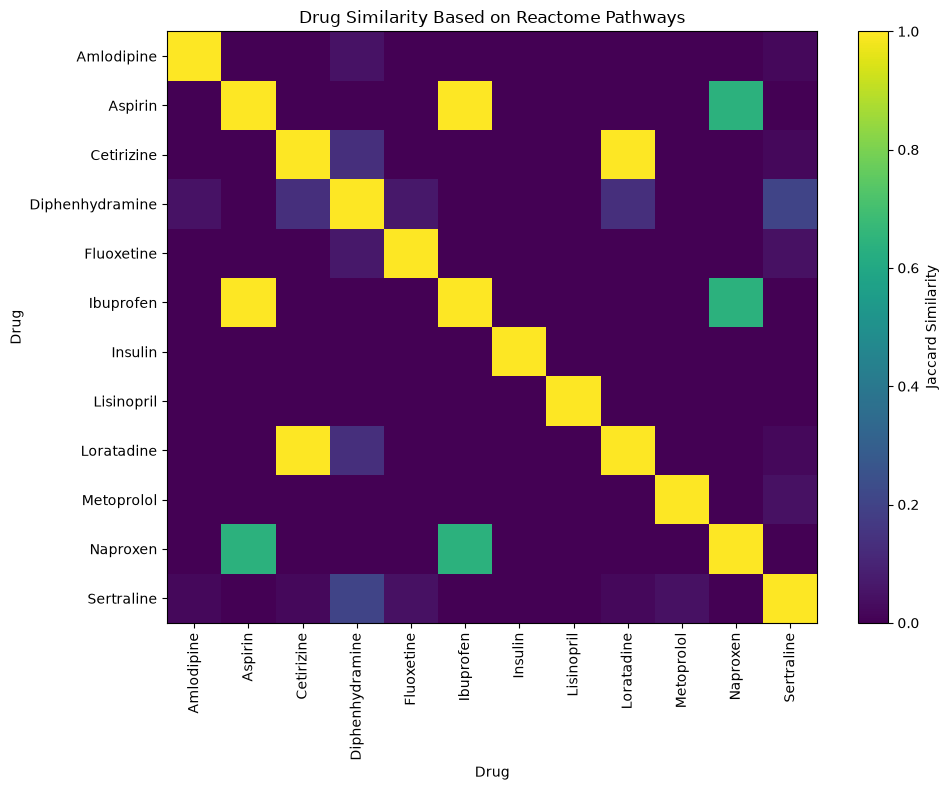

In [12]:
#heatmap

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

plt.imshow(
    jaccard_df,
    aspect="auto"
)

plt.xticks(
    range(len(jaccard_df.columns)),
    jaccard_df.columns,
    rotation=90
)

plt.yticks(
    range(len(jaccard_df.index)),
    jaccard_df.index
)

plt.colorbar(label="Jaccard Similarity")

plt.title("Drug Similarity Based on Reactome Pathways")
plt.xlabel("Drug")
plt.ylabel("Drug")

plt.tight_layout()
plt.show()

In [ ]:
# Identify targets that did not receive a Reactome pathway
unmapped_targets = targets[
    ~targets["UniProt"].isin(pathways_found["UniProt"])
].copy()

print(unmapped_targets)

unmapped_targets.to_csv(
    "C:/Katieryb/Pipelines/proteins/unmapped_reactome_targets.csv",
    index=False
)

"""

drug_pathways.csv
        ↓
used for analysis

unmapped_reactome_targets.csv
        ↓
documented limitation
"""


#Let's also create a drug → pathway names summary. This will make it much easier to inspect what model is actually seeing.
pathway_summary = (
    drug_pathways
    .groupby("Drug")
    .agg(
        Number_of_Pathways=("Pathway_ID", "nunique"),
        Pathways=("Pathway_Name", lambda x: "; ".join(sorted(set(x))))
    )
    .reset_index()
)

pathway_summary

pathway_summary.to_csv(
    "C:/Katieryb/Pipelines/proteins/drug_pathway_summary.csv",
    index=False
)



               Drug      ChEMBL_ID  \
8   Diphenhydramine      CHEMBL657   
30       Amlodipine  CHEMBL1200402   
54       Sertraline      CHEMBL809   

                                              Protein     Gene UniProt  \
8                               Histamine H1 receptor     HRH1  P31389   
30  Voltage-dependent L-type calcium channel subun...  CACNA1F  O60840   
54                                        Transporter   Slc6a2  Q9WTR4   

       Target_Type  
8   SINGLE PROTEIN  
30  PROTEIN FAMILY  
54  SINGLE PROTEIN  


In [ ]:
#assuming 'targets' contains 14 ChEMBL drugs and 'drug_pathways' contains 12 merged drugs
chembl_drug_set = set(targets["Drug"].unique())
reactome_drug_set = set(drug_pathways["Drug"].unique())

dropped_by_reactome = chembl_drug_set - reactome_drug_set

print("=== Reactome Pathway Dropout Diagnostic ===")
print(f"Drugs with proteins but ZERO Reactome pathways ({len(dropped_by_reactome)}): {dropped_by_reactome}")

=== Reactome Pathway Dropout Diagnostic ===
Drugs with proteins but ZERO Reactome pathways (0): set()


In [ ]:
import pandas as pd

# 1. Load the two raw files
targets = pd.read_csv("C:/Katieryb/Pipelines/proteins/drug_targets.csv")
pathways = pd.read_csv("C:/Katieryb/Pipelines/proteins/gene_pathways.csv") 

# 2. Get the clean list of paths that were actually found
pathways_found = pathways[pathways["Pathway_Status"] == "Found"]

# 3. Recreate the true pipeline merge using UniProt as the connecting bridge
# This maps: Drug -> UniProt -> Pathway
merged_pipeline = pd.merge(
    targets[["Drug", "UniProt"]], 
    pathways_found[["UniProt", "Pathway_ID", "Pathway_Name"]], 
    on="UniProt"
)

# 4 define absolute starting 17 drugs to audit the whole project
original_17 = {
    "Ibuprofen", "Acetaminophen", "Aspirin", "Naproxen", "Diphenhydramine",
    "Loratadine", "Cetirizine", "Amoxicillin", "Azithromycin", "Lisinopril",
    "Metoprolol", "Amlodipine", "Metformin", "Fluoxetine", "Sertraline",
    "Clozapine", "Insulin"
}

# 5 extract unique drugs at each milestone
drugs_in_chembl = set(targets["Drug"].unique())
drugs_in_reactome = set(merged_pipeline["Drug"].unique())

print("FINAL PIPELINE AUDIT REPORT")
print(f"Initial Starting Cohort:       {len(original_17)} drugs")
print(f"Survives ChEMBL Extraction:    {len(drugs_in_chembl)} drugs")
print(f"Survives Reactome Integration: {len(drugs_in_reactome)} drugs")

# Find exactly who dropped out and where
dropped_at_chembl = original_17 - drugs_in_chembl
dropped_at_reactome = drugs_in_chembl - drugs_in_reactome

print(f". Dropped at ChEMBL Step ({len(dropped_at_chembl)}):")
print(f"   {dropped_at_chembl if dropped_at_chembl else 'None! All cleared.'}")

print(f"\n 2. Dropped at Reactome Step ({len(dropped_at_reactome)}):")
print(f"   {dropped_at_reactome if dropped_at_reactome else 'None! All cleared.'}")

print("\n3. Final 12 Active Core Drugs on Heatmap:")
print(f"   {sorted(list(drugs_in_reactome))}")



       FINAL PIPELINE AUDIT REPORT                
Initial Starting Cohort:       17 drugs
Survives ChEMBL Extraction:    12 drugs
Survives Reactome Integration: 12 drugs
--------------------------------------------------
❌ 1. Dropped at ChEMBL Step (5):
   {'Amoxicillin', 'Acetaminophen', 'Clozapine', 'Metformin', 'Azithromycin'}

❌ 2. Dropped at Reactome Step (0):
   None! All cleared.

🎯 3. Final 12 Active Core Drugs on Heatmap:
   ['Amlodipine', 'Aspirin', 'Cetirizine', 'Diphenhydramine', 'Fluoxetine', 'Ibuprofen', 'Insulin', 'Lisinopril', 'Loratadine', 'Metoprolol', 'Naproxen', 'Sertraline']
